# VAEs

## Importing PyTorch Modules

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


## Hyperparameters Configuration

In [ ]:
BATCH_SIZE = 128
LATENT_DIM = 20
HIDDEN_DIM = 400
EPOCHS = 30
LR = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Loading MNIST Dataset

In [ ]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


## Defining the Variational Autoencoder (VAE) Architecture

In [ ]:
class VAE(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)

        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):

        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)

        eps = torch.randn_like(std)

        z = mu + std * eps

        return z

    def decode(self, z):

        h = F.relu(self.fc3(z))
        h = F.relu(self.fc4(h))

        logits = self.fc_out(h)

        return logits

    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        logits = self.decode(z)

        return logits, mu, logvar


## Defining the VAE Loss Function (Reconstruction + KL Divergence)

In [ ]:
def vae_loss(logits, x, mu, logvar):

    reconstruction_loss = F.binary_cross_entropy_with_logits(
        logits,
        x,
        reduction="sum"
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = reconstruction_loss + kl_loss

    return total_loss, reconstruction_loss, kl_loss


## Initializing the VAE Model

In [ ]:
model = VAE(
    input_dim=784,
    hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)


## Training Loop Preparation

In [ ]:
train_losses = []
reconstruction_losses = []
kl_losses = []

for epoch in range(1, EPOCHS + 1):

    model.train()

    total_loss = 0
    total_recon = 0
    total_kl = 0

    for images, _ in train_loader:

        images = images.view(images.size(0), -1).to(device)

        optimizer.zero_grad()

        logits, mu, logvar = model(images)

        loss, recon_loss, kl_loss = vae_loss(
            logits,
            images,
            mu,
            logvar
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    avg_loss = total_loss / len(train_dataset)
    avg_recon = total_recon / len(train_dataset)
    avg_kl = total_kl / len(train_dataset)

    train_losses.append(avg_loss)
    reconstruction_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] "
        f"Loss: {avg_loss:.4f} "
        f"Recon: {avg_recon:.4f} "
        f"KL: {avg_kl:.4f}"
    )


Epoch [01/30] Loss: 178.6663 Recon: 171.4464 KL: 7.2199
Epoch [02/30] Loss: 128.4376 Recon: 114.0185 KL: 14.4191
Epoch [03/30] Loss: 118.2691 Recon: 102.2975 KL: 15.9715
Epoch [04/30] Loss: 113.3202 Recon: 96.4129 KL: 16.9073
Epoch [05/30] Loss: 110.5794 Recon: 93.2691 KL: 17.3103
Epoch [06/30] Loss: 108.8417 Recon: 91.2523 KL: 17.5894
Epoch [07/30] Loss: 107.5571 Recon: 89.7794 KL: 17.7778
Epoch [08/30] Loss: 106.4883 Recon: 88.5316 KL: 17.9567
Epoch [09/30] Loss: 105.6325 Recon: 87.4632 KL: 18.1693
Epoch [10/30] Loss: 104.7627 Recon: 86.3352 KL: 18.4275
Epoch [11/30] Loss: 103.9927 Recon: 85.3521 KL: 18.6405
Epoch [12/30] Loss: 103.3503 Recon: 84.5116 KL: 18.8387
Epoch [13/30] Loss: 102.7305 Recon: 83.7821 KL: 18.9484
Epoch [14/30] Loss: 102.3742 Recon: 83.3280 KL: 19.0462
Epoch [15/30] Loss: 101.9389 Recon: 82.7986 KL: 19.1403
Epoch [16/30] Loss: 101.5417 Recon: 82.3488 KL: 19.1929
Epoch [17/30] Loss: 101.2608 Recon: 82.0016 KL: 19.2592
Epoch [18/30] Loss: 100.9543 Recon: 81.6919 KL

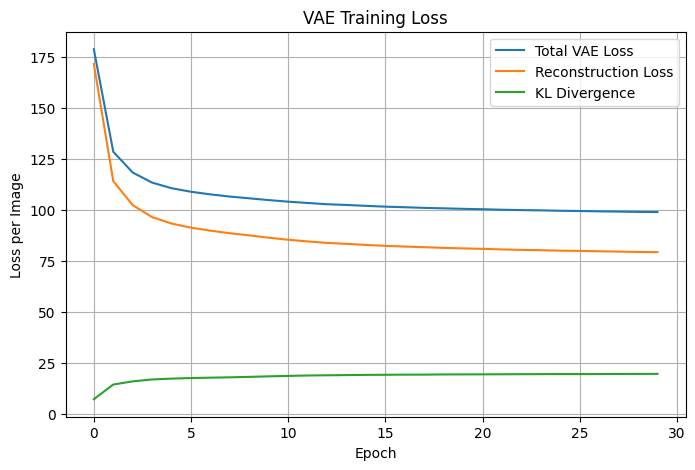

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Total VAE Loss")
plt.plot(reconstruction_losses, label="Reconstruction Loss")
plt.plot(kl_losses, label="KL Divergence")

plt.xlabel("Epoch")
plt.ylabel("Loss per Image")
plt.title("VAE Training Loss")
plt.legend()
plt.grid()

plt.show()


## Generating New Samples from Latent Space

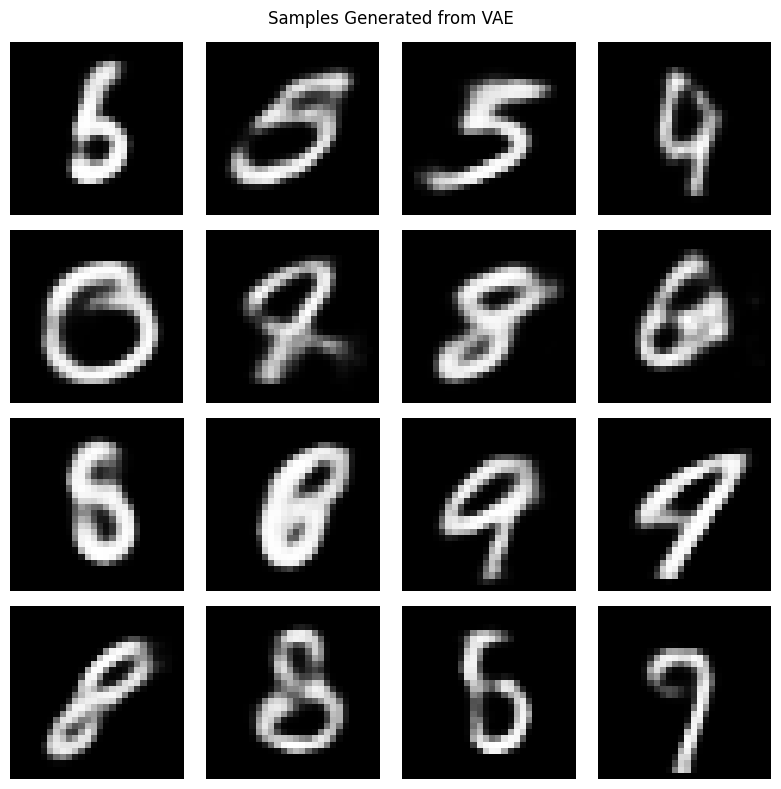

In [ ]:
model.eval()

with torch.no_grad():

    z = torch.randn(16, LATENT_DIM).to(device)

    logits = model.decode(z)

    samples = torch.sigmoid(logits)

    samples = samples.view(-1, 28, 28).cpu()

fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):

    ax.imshow(samples[i], cmap="gray")
    ax.axis("off")

plt.suptitle("Samples Generated from VAE")
plt.tight_layout()

plt.show()


## Reconstructing Original Images

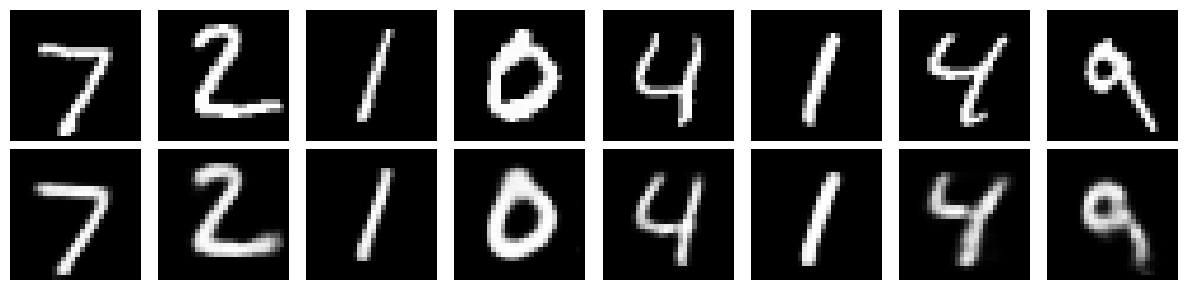

In [ ]:
model.eval()

images, labels = next(iter(test_loader))

images_flat = images.view(images.size(0), -1).to(device)

with torch.no_grad():

    logits, mu, logvar = model(images_flat)

    reconstructions = torch.sigmoid(logits)

reconstructions = reconstructions.view(-1, 28, 28).cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))

for i in range(8):

    axes[0, i].imshow(images[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")

    axes[1, i].imshow(reconstructions[i], cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Reconstructed")

plt.tight_layout()
plt.show()


In [ ]:
import json
import torch

model_path = "vae_mnist.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": 784,
    "hidden_dim": HIDDEN_DIM,
    "latent_dim": LATENT_DIM,
}, model_path)

results = {
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "latent_dim": LATENT_DIM,
    "hidden_dim": HIDDEN_DIM,

    "train_losses": train_losses,
    "reconstruction_losses": reconstruction_losses,
    "kl_losses": kl_losses,

    "final_loss": train_losses[-1],
    "final_reconstruction_loss": reconstruction_losses[-1],
    "final_kl_loss": kl_losses[-1],
}

with open("vae_training_results.json", "w") as f:
    json.dump(results, f, indent=4)

print(f"Model saved to: {model_path}")
print("Training results saved to: vae_training_results.json")


Model saved to: vae_mnist.pt
Training results saved to: vae_training_results.json


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

model.eval()

latent_means = []
labels = []

with torch.no_grad():

    for images, y in test_loader:

        images = images.view(images.size(0), -1).to(device)

        mu, logvar = model.encode(images)

        latent_means.append(mu.cpu().numpy())
        labels.append(y.numpy())

latent_means = np.concatenate(latent_means, axis=0)
labels = np.concatenate(labels, axis=0)

print("Latent representation shape:", latent_means.shape)


Latent representation shape: (10000, 20)


## Visualizing Latent Space using PCA

In [ ]:
pca = PCA(n_components=2)

latent_2d = pca.fit_transform(latent_means)

print("2D latent representation shape:", latent_2d.shape)

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)


2D latent representation shape: (10000, 2)
Explained variance ratio: [0.12181392 0.10896155]
Total explained variance: 0.23077548


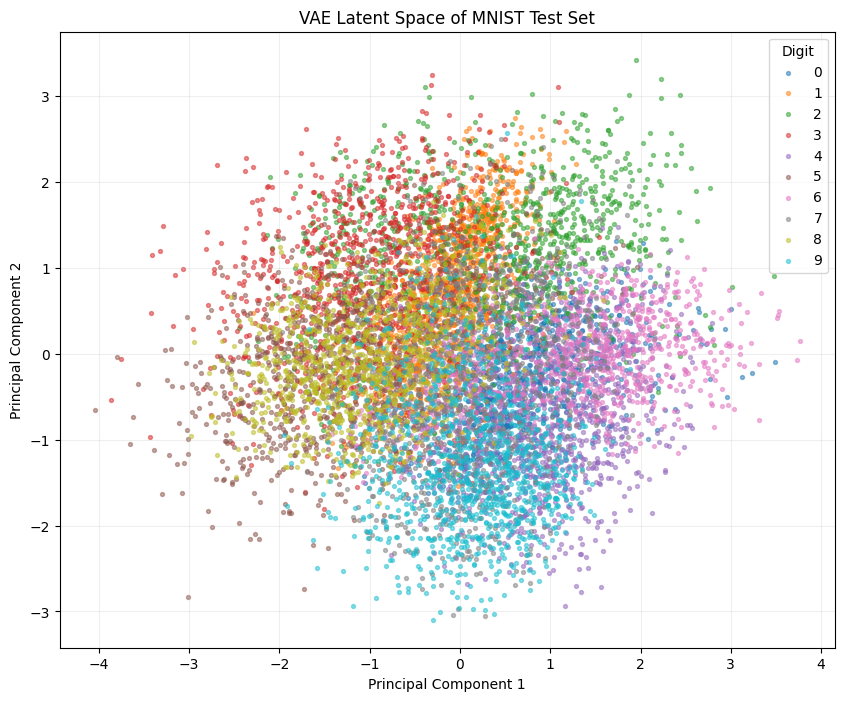

In [ ]:
plt.figure(figsize=(10, 8))

for digit in range(10):

    mask = labels == digit

    plt.scatter(
        latent_2d[mask, 0],
        latent_2d[mask, 1],
        s=8,
        alpha=0.5,
        label=str(digit)
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("VAE Latent Space of MNIST Test Set")
plt.legend(title="Digit")
plt.grid(alpha=0.2)

plt.show()
